# Ridge T-learner Analysis
Full pipeline with TL (OLS) and TL (Ridge) compared side by side.
Ridge uses per-group lambda selection via OOF R² across all 20 weeks jointly.

In [ ]:
import os


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from helper import (
    ALL_WEEKS,
    FEATURES_DEFAULT,
    METHOD_COLORS,
    METHOD_LABELS,
    _RIDGE_LAMBDAS_CUSTOM,
    add_horizon_outcomes_by_experiment,
    build_experiment_data_summary,
    build_experiment_summary,
    build_table_figure1_density_stats,
    compute_best_feature_correlations,
    plot_figure1_distribution_grid,
    plot_figure2_correlations,
    plot_figure3_balance_grid,
    plot_users_by_experiment_stacked,
    run_balance_analysis,
    run_method_evaluation_with_ridge,
    build_table_1,
    build_table_2,
    build_table_figure8_weekly_summary,
    build_table_figure9_ds_by_experiment,
    build_standardized_ate_error_tables,
    plot_figure4,
    plot_figure5,
)


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Auth & Data Load

In [ ]:
#load df here.

/Users/jurgis.adomaitis/vinted/exp-metrics-bakis/.venv/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Loaded 13,678,514 rows, 9 experiments


## 2. Setup

In [ ]:
df = add_horizon_outcomes_by_experiment(df, ALL_WEEKS)

exp_summary_df, exp_label_map = build_experiment_summary(df)
exp_order = exp_summary_df["experiment_id"].tolist()

display(exp_summary_df)

exp_data_summary_df = build_experiment_data_summary(df, exp_summary_df)
display(exp_data_summary_df)

In [ ]:
plot_users_by_experiment_stacked(df, label_map=exp_label_map, hide_experiment_names=True)

## 3. Y Distributions (W1, W10, W20)

In [ ]:
plot_figure1_distribution_grid(
    df, exp_order=exp_order, label_map=exp_label_map, weeks=(1, 10, 20)
)
display(build_table_figure1_density_stats(
    df, exp_order=exp_order, label_map=exp_label_map, weeks=(1, 10, 20)
))

## 4. Feature Correlations

In [ ]:
best_corr_df = compute_best_feature_correlations(
    df, features=FEATURES_DEFAULT, exp_order=exp_order, target_week=20
)
plot_figure2_correlations(best_corr_df, label_map=exp_label_map)
display(best_corr_df)

## 5. Group Balance (SMD)

In [ ]:
balance_by_exp, balance_summary_df = run_balance_analysis(
    df, features=FEATURES_DEFAULT, exp_order=exp_order, label_map=exp_label_map
)
plot_figure3_balance_grid(balance_by_exp, exp_order=exp_order, label_map=exp_label_map)
display(balance_summary_df)

## 6. Method Evaluation — All Weeks (OLS + Ridge)

In [ ]:
results_df, r2_df_ols, r2_df_ridge, cuped_feature_df = run_method_evaluation_with_ridge(
    df,
    features=FEATURES_DEFAULT,
    exp_order=exp_order,
    weeks=ALL_WEEKS,
)
print(f"Methods in results: {sorted(results_df['method'].unique())}")
display(results_df.head(10))

In [18]:
# Kaip build_table_1, bet su TL (OLS) ir TL (Ridge)
d20 = results_df[results_df["week"] == 20].copy()
d20 = d20[d20["method"].isin(["winsor", "cuped", "tl_ols", "tl_ridge"])]

pvt = d20.pivot_table(index="experiment_id", columns="method", values="ds", aggfunc="first")
pvt = pvt.rename(columns={
    "winsor": "DS_winsor_%",
    "cuped": "DS_cuped_%",
    "tl_ols": "DS_TL_OLS_%",
    "tl_ridge": "DS_TL_Ridge_%",
}) * 100

table_1_ridge = (
    exp_summary_df.set_index("experiment_id")
    .join(pvt)
    .reset_index()
)
table_1_ridge["Eksperimentas"] = table_1_ridge["experiment_id"].map(exp_label_map)
table_1_ridge = table_1_ridge[
    ["Eksperimentas", "n_e", "DS_winsor_%", "DS_cuped_%", "DS_TL_OLS_%", "DS_TL_Ridge_%"]
]

display(table_1_ridge)

# Jei nori ir senąją (tik OLS) – vis dar veiks:
display(build_table_1(results_df, exp_summary_df, exp_label_map))

,Eksperimentas,n_e,DS_winsor_%,DS_cuped_%,DS_TL_OLS_%,DS_TL_Ridge_%
0,e_1,5675498,41.928965,11.143832,15.040825,15.040832
1,e_2,3169962,44.784278,7.711460,10.652640,10.652644
2,e_3,1864177,37.754577,15.416298,18.685154,18.685353
3,e_4,1201695,48.310691,5.752621,8.926088,8.926916
4,e_5,932512,50.859089,12.361573,15.520729,15.521114
5,e_6,645076,51.833498,9.449009,12.075927,12.076475
6,e_7,137471,31.188855,12.378333,16.016127,16.019161
7,e_8,30082,36.017946,7.335587,9.315827,9.324580
8,e_9,22041,56.772854,4.472059,6.027989,6.045996


,Eksperimentas,n_e,DS_winsor_%,DS_cuped_%,DS_tl_%
0,e_1,5.675498e+06,41.928965,11.143832,15.040825
1,e_2,3.169962e+06,44.784278,7.711460,10.652640
2,e_3,1.864177e+06,37.754577,15.416298,18.685154
3,e_4,1.201695e+06,48.310691,5.752621,8.926088
4,e_5,9.325120e+05,50.859089,12.361573,15.520729
5,e_6,6.450760e+05,51.833498,9.449009,12.075927
6,e_7,1.374710e+05,31.188855,12.378333,16.016127
7,e_8,3.008200e+04,36.017946,7.335587,9.315827
8,e_9,2.204100e+04,56.772854,4.472059,6.027989
9,Vidurkis,1.519835e+06,44.383417,9.557864,12.473478


In [19]:
# Mediana per savaites – reikia rankiniu būdu įtraukti tl_ridge
d = results_df[results_df["method"].isin(["winsor", "cuped", "tl_ols", "tl_ridge"])].copy()
weekly = (
    d.groupby(["week", "method"])["ds"]
    .median()
    .reset_index(name="Dispersijos sumažinimo mediana")
)
weekly["Dispersijos sumažinimo mediana"] *= 100
weekly["Metodas"] = weekly["method"].map(METHOD_LABELS)
display(weekly[["Savaitė" if "Savaitė" in weekly.columns else "week", "Metodas", "Dispersijos sumažinimo mediana"]]
        .rename(columns={"week": "Savaitė"})
        .sort_values(["Savaitė", "Metodas"]))

# Arba senoji (be Ridge):
display(build_table_figure8_weekly_summary(results_df))

# DS pagal eksperimentą ir savaitę (be Ridge):
display(build_table_figure9_ds_by_experiment(results_df, exp_summary_df, exp_label_map))

# Su Ridge:
ds_by_exp = (
    d.assign(
        Eksperimentas=lambda x: x["experiment_id"].map(exp_label_map),
        Metodas=lambda x: x["method"].map(METHOD_LABELS),
        **{"Dispersijos sumažinimas (%)": lambda x: 100 * x["ds"]},
    )[["Eksperimentas", "week", "Metodas", "Dispersijos sumažinimas (%)"]]
    .rename(columns={"week": "Savaitė"})
    .sort_values(["Eksperimentas", "Savaitė", "Metodas"])
)
display(ds_by_exp)

,Savaitė,Metodas,Dispersijos sumažinimo mediana
0,1,CUPED,3.760336
1,1,TL (OLS),5.118840
2,1,TL (Ridge),5.118845
3,1,Variacinės eilutės karpymas,53.521945
4,2,CUPED,4.940693
...,...,...,...
75,19,Variacinės eilutės karpymas,44.736912
76,20,CUPED,9.449009
77,20,TL (OLS),12.075927
78,20,TL (Ridge),12.076475


,Savaitė,Metodas,Dispersijos sumažinimo mediana
0,1,CUPED,3.760336
20,1,TL (OLS),5.118840
40,1,Variacinės eilutės karpymas,53.521945
1,2,CUPED,4.940693
21,2,TL (OLS),6.666441
41,2,Variacinės eilutės karpymas,50.428185
2,3,CUPED,5.966123
22,3,TL (OLS),7.312707
42,3,Variacinės eilutės karpymas,47.955688
3,4,CUPED,6.637400


,Eksperimentas,n_e,Savaitė,Metodas,Dispersijos sumažinimas (%)
1,e_1,5675498,1,CUPED,3.760336
2,e_1,5675498,1,TL (OLS),5.118840
0,e_1,5675498,1,Variacinės eilutės karpymas,53.807570
4,e_1,5675498,2,CUPED,4.940693
5,e_1,5675498,2,TL (OLS),6.666441
...,...,...,...,...,...
536,e_9,22041,19,TL (OLS),5.696594
534,e_9,22041,19,Variacinės eilutės karpymas,57.703567
538,e_9,22041,20,CUPED,4.472059
539,e_9,22041,20,TL (OLS),6.027989


,Eksperimentas,Savaitė,Metodas,Dispersijos sumažinimas (%)
2,e_1,1,CUPED,3.760336
3,e_1,1,TL (OLS),5.118840
4,e_1,1,TL (Ridge),5.118845
1,e_1,1,Variacinės eilutės karpymas,53.807570
7,e_1,2,CUPED,4.940693
...,...,...,...,...
891,e_9,19,Variacinės eilutės karpymas,57.703567
897,e_9,20,CUPED,4.472059
898,e_9,20,TL (OLS),6.027989
899,e_9,20,TL (Ridge),6.045996


## 7. Selected Lambda per Experiment per Group

In [9]:
# Lambda is constant per (experiment, group) — show W20 rows only
lam_summary = (
    r2_df_ridge[r2_df_ridge["week"] == 20][["experiment_id", "lam0", "lam1"]]
    .copy()
)
lam_summary["Eksperimentas"] = lam_summary["experiment_id"].map(exp_label_map)
lam_summary = lam_summary[["Eksperimentas", "lam0", "lam1"]].rename(
    columns={"lam0": "λ (kontrolinė gr.)", "lam1": "λ (eksperimentinė gr.)"}
)
display(lam_summary)

,Eksperimentas,λ (kontrolinė gr.),λ (eksperimentinė gr.)
19,e_1,50.0,50.0
39,e_2,50.0,0.1
59,e_3,50.0,50.0
79,e_4,50.0,50.0
99,e_5,50.0,50.0
119,e_6,50.0,50.0
139,e_7,50.0,50.0
159,e_8,50.0,50.0
179,e_9,50.0,50.0


## 8. Dispersijos sumažinimas laike — TL (OLS) vs TL (Ridge)

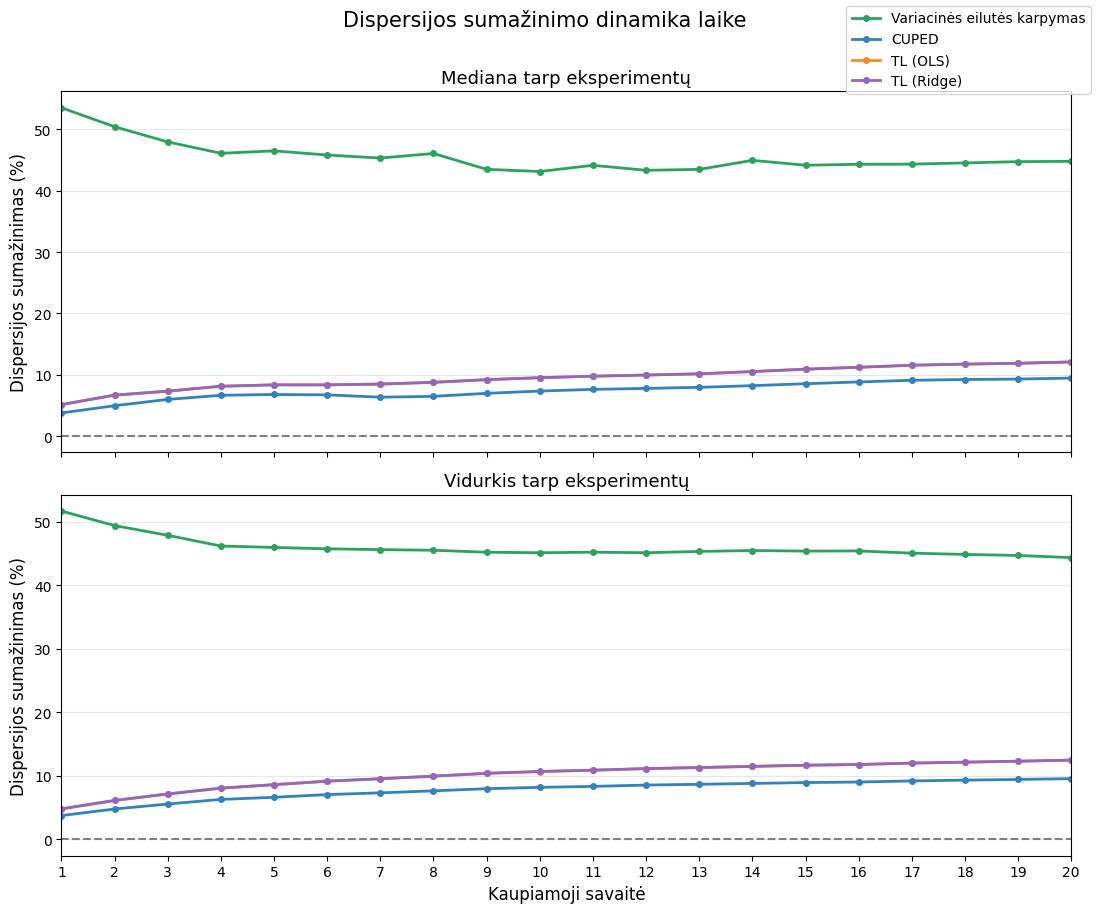

In [10]:
d = results_df[results_df["method"].isin(["winsor", "cuped", "tl_ols", "tl_ridge"])].copy()
methods = ["winsor", "cuped", "tl_ols", "tl_ridge"]

fig, (ax_med, ax_mean) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

for m in methods:
    g = d[d["method"] == m].groupby("week")["ds"]
    ax_med.plot(
        g.median().index, 100 * g.median().values,
        color=METHOD_COLORS[m], marker="o", markersize=4, linewidth=2,
        label=METHOD_LABELS[m],
    )
    ax_mean.plot(
        g.mean().index, 100 * g.mean().values,
        color=METHOD_COLORS[m], marker="o", markersize=4, linewidth=2,
        label=METHOD_LABELS[m],
    )

for ax, title in [
    (ax_med, "Mediana tarp eksperimentų"),
    (ax_mean, "Vidurkis tarp eksperimentų"),
]:
    ax.axhline(0, linestyle="--", color="gray")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Dispersijos sumažinimas (%)", fontsize=12)
    ax.set_xlim(min(ALL_WEEKS), max(ALL_WEEKS))
    ax.set_xticks(ALL_WEEKS)
    ax.grid(axis="y", alpha=0.3)

ax_mean.set_xlabel("Kaupiamoji savaitė", fontsize=12)
fig.legend([METHOD_LABELS[m] for m in methods], loc="upper right", ncol=1)
fig.suptitle("Dispersijos sumažinimo dinamika laike", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 9. Dispersijos sumažinimas pagal eksperimentą — TL (OLS) vs TL (Ridge)

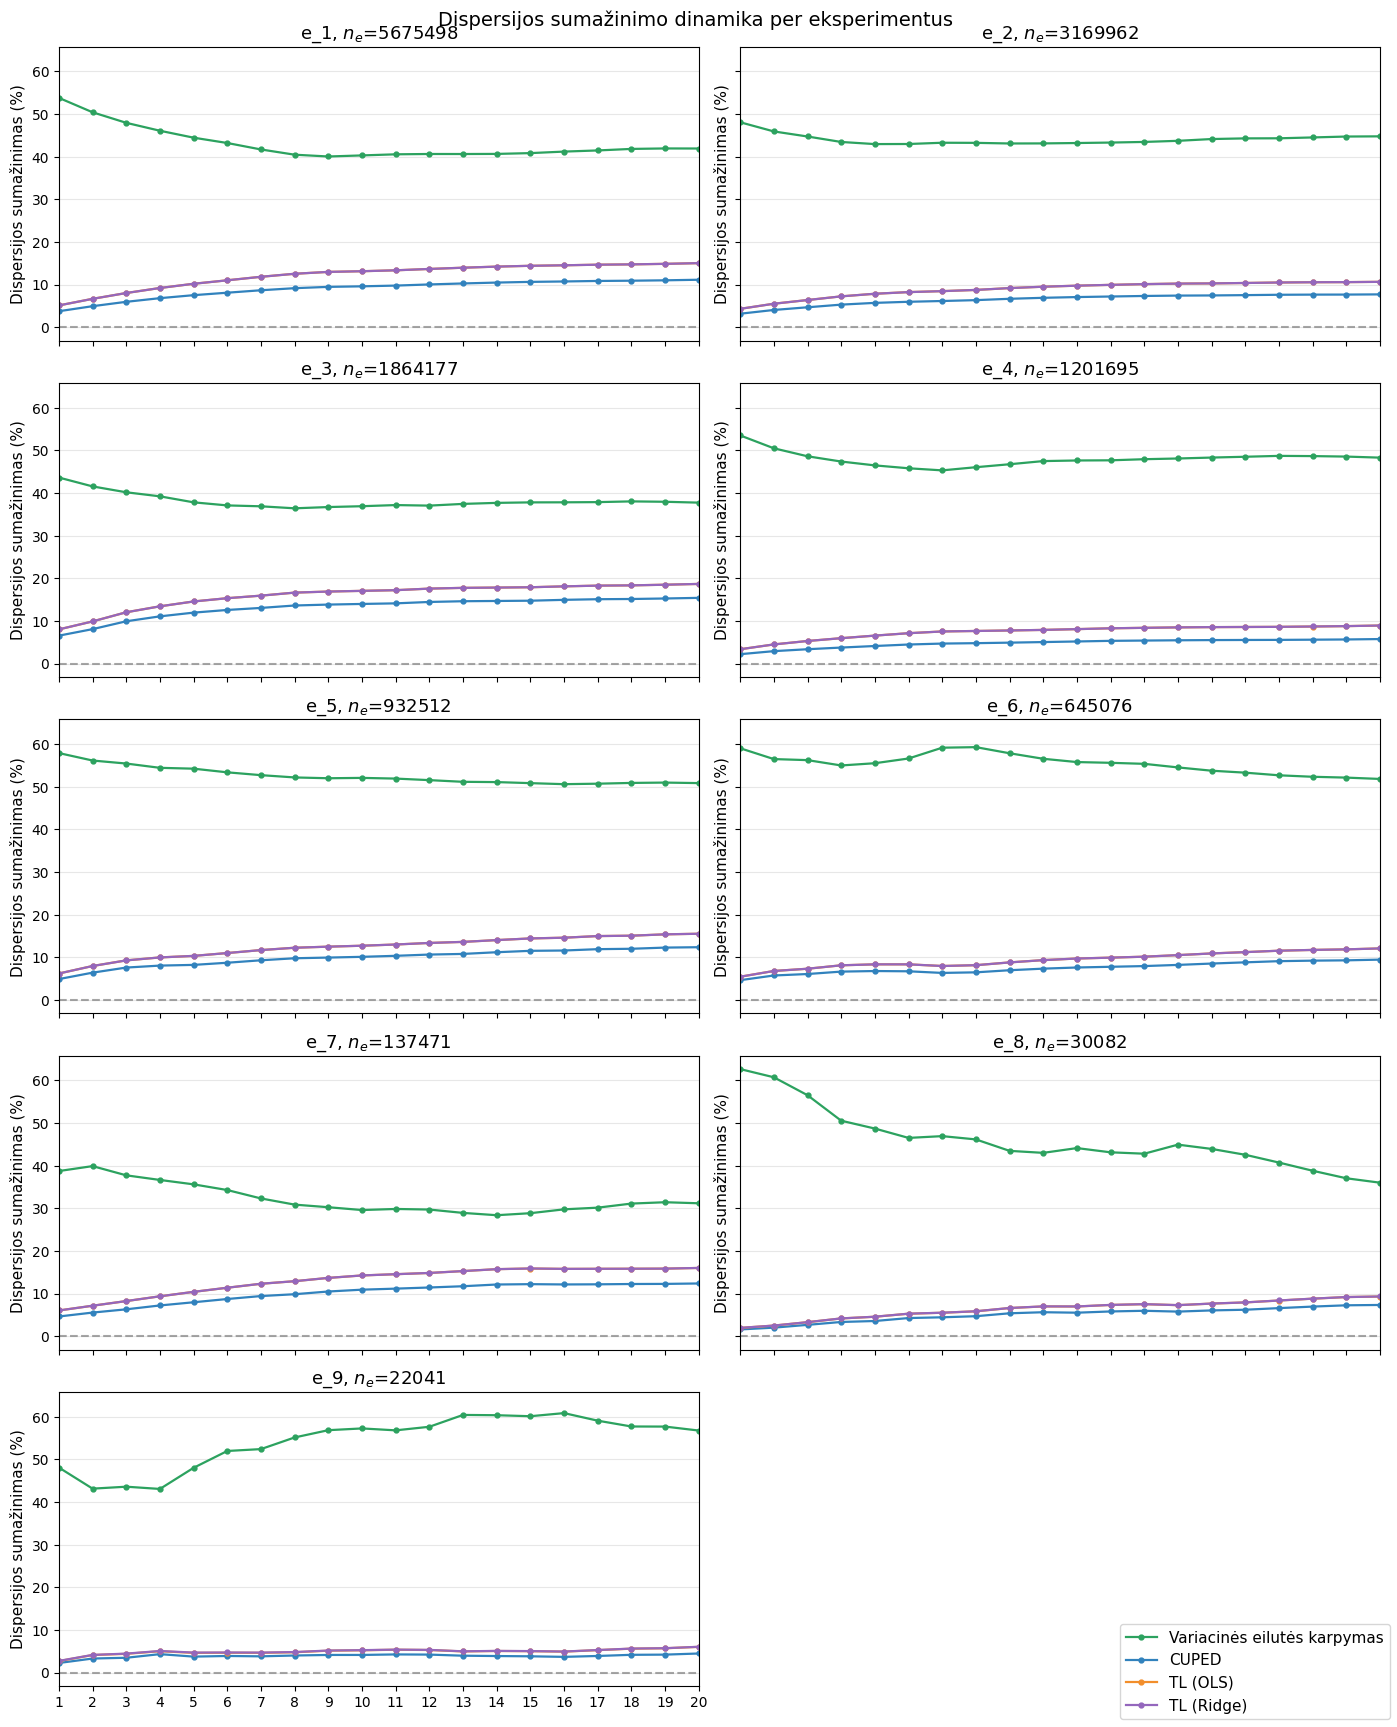

In [11]:
d = results_df[results_df["method"].isin(["winsor", "cuped", "tl_ols", "tl_ridge"])].copy()
methods = ["winsor", "cuped", "tl_ols", "tl_ridge"]
n_map = dict(zip(exp_summary_df["experiment_id"], exp_summary_df["n_e"]))

n = len(exp_order)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, exp_id in enumerate(exp_order):
    ax = axes[i]
    sube = d[d["experiment_id"] == exp_id]
    for m in methods:
        s = sube[sube["method"] == m].sort_values("week")
        ax.plot(
            s["week"], 100 * s["ds"],
            color=METHOD_COLORS[m], marker="o", markersize=3.5, linewidth=1.6,
            label=METHOD_LABELS[m],
        )
    ax.axhline(0, linestyle="--", color="gray", alpha=0.7)
    ax.set_xlim(min(ALL_WEEKS), max(ALL_WEEKS))
    ax.set_xticks(ALL_WEEKS)
    ax.set_ylabel("Dispersijos sumažinimas (%)", fontsize=11)
    ax.set_title(f"{exp_label_map.get(exp_id, exp_id)}, $n_e$={n_map.get(exp_id)}", fontsize=13)
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.legend([METHOD_LABELS[m] for m in methods], loc="lower right", ncol=1, fontsize=11)
fig.suptitle("Dispersijos sumažinimo dinamika per eksperimentus", fontsize=14)
plt.tight_layout()
plt.show()

## 10. ATE dinamika — TL (OLS) vs TL (Ridge)

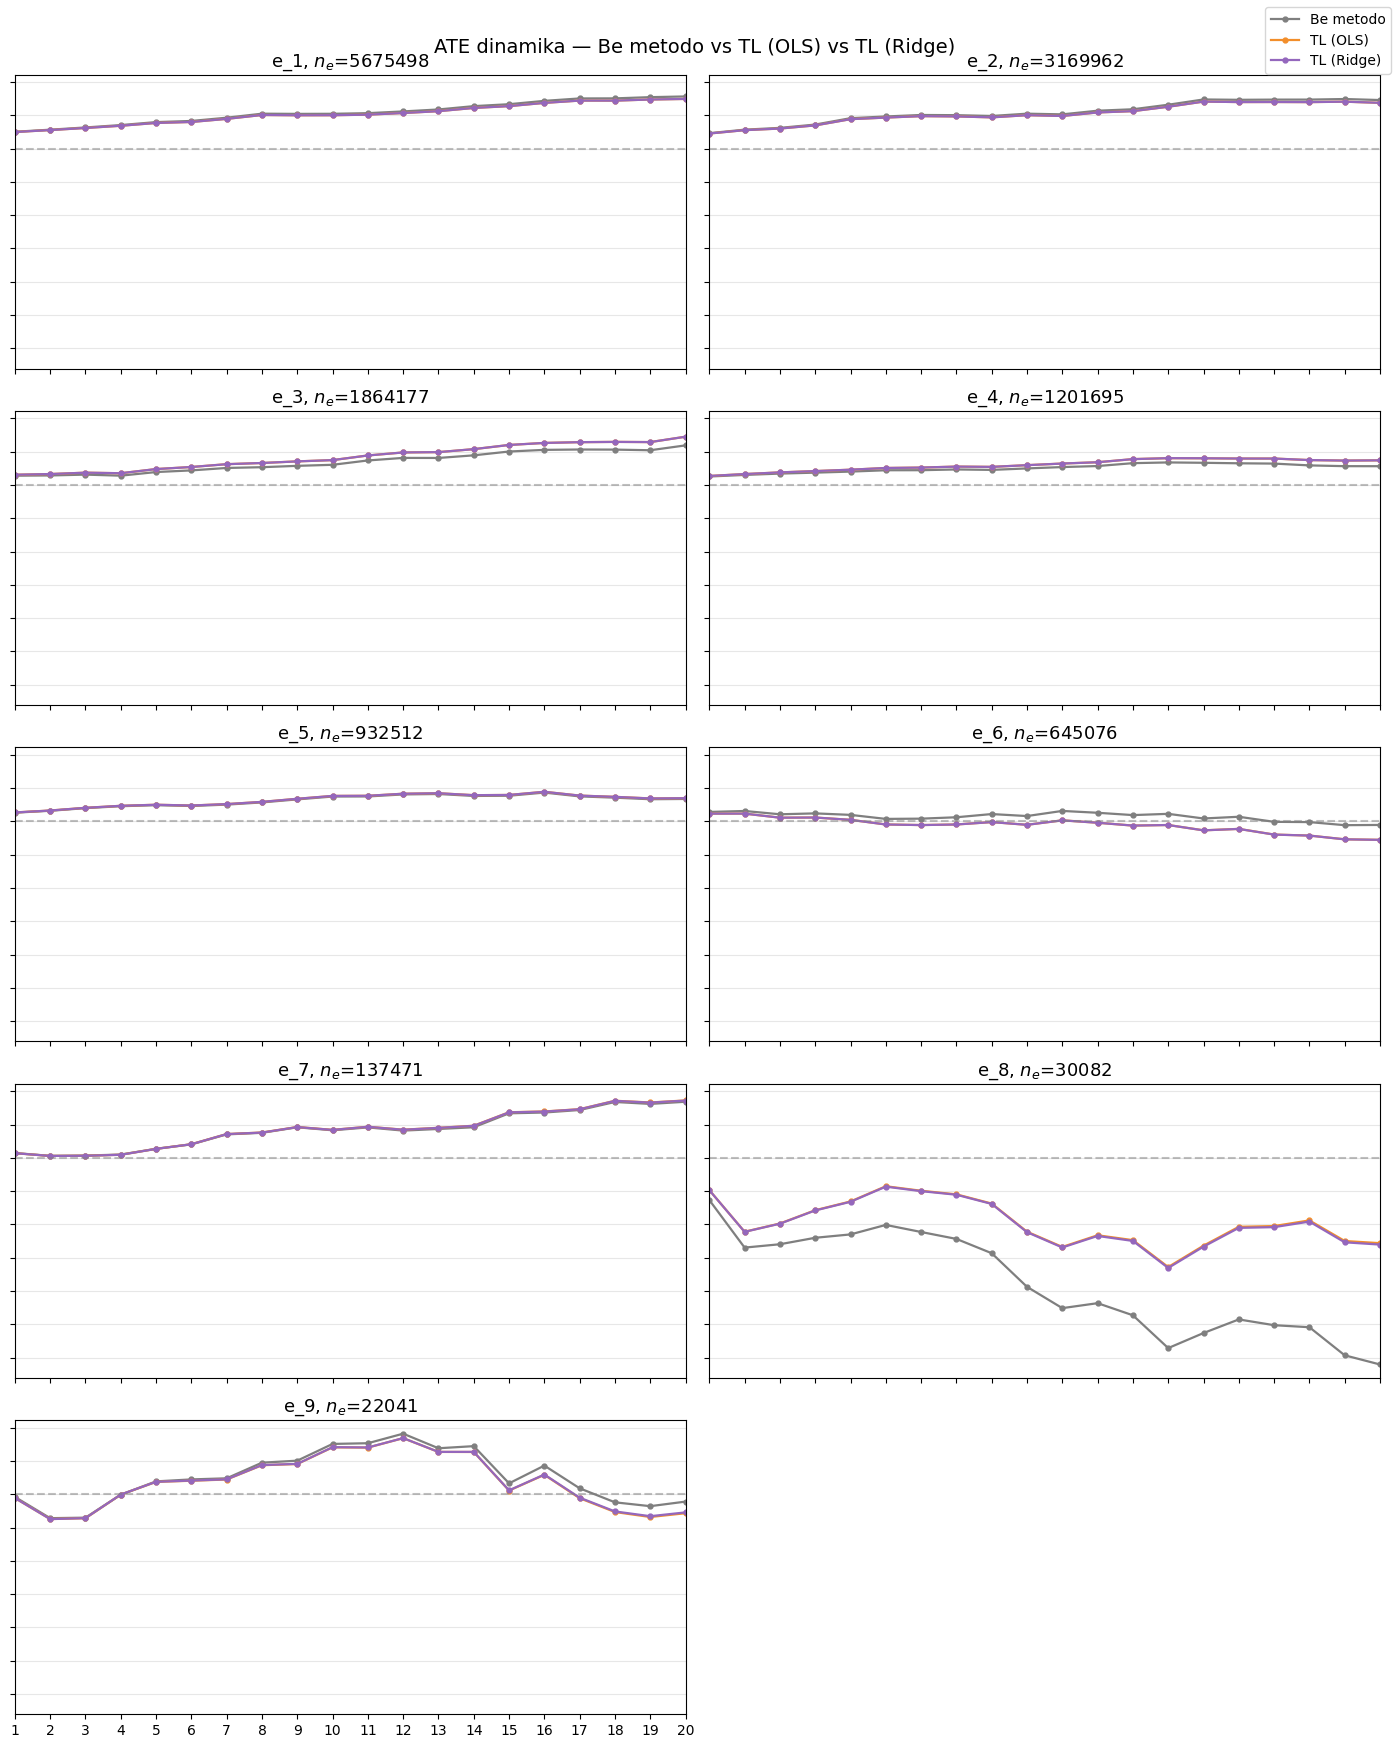

In [12]:
d = results_df[results_df["method"].isin(["naive", "tl_ols", "tl_ridge"])].copy()
methods_ate = ["naive", "tl_ols", "tl_ridge"]
n_map = dict(zip(exp_summary_df["experiment_id"], exp_summary_df["n_e"]))

n = len(exp_order)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, exp_id in enumerate(exp_order):
    ax = axes[i]
    sube = d[d["experiment_id"] == exp_id]
    for m in methods_ate:
        s = sube[sube["method"] == m].sort_values("week")
        ax.plot(
            s["week"], s["tau"],
            color=METHOD_COLORS[m], marker="o", markersize=3.5, linewidth=1.6,
            label=METHOD_LABELS[m],
        )
    ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
    ax.set_xlim(min(ALL_WEEKS), max(ALL_WEEKS))
    ax.set_xticks(ALL_WEEKS)
    ax.set_yticklabels([])
    ax.set_title(f"{exp_label_map.get(exp_id, exp_id)}, $n_e$={n_map.get(exp_id)}", fontsize=13)
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.legend([METHOD_LABELS[m] for m in methods_ate], loc="upper right", ncol=1)
fig.suptitle("ATE dinamika — Be metodo vs TL (OLS) vs TL (Ridge)", fontsize=14)
plt.tight_layout()
plt.show()

## 11. $R^2$ dinamika — TL (OLS) vs TL (Ridge)

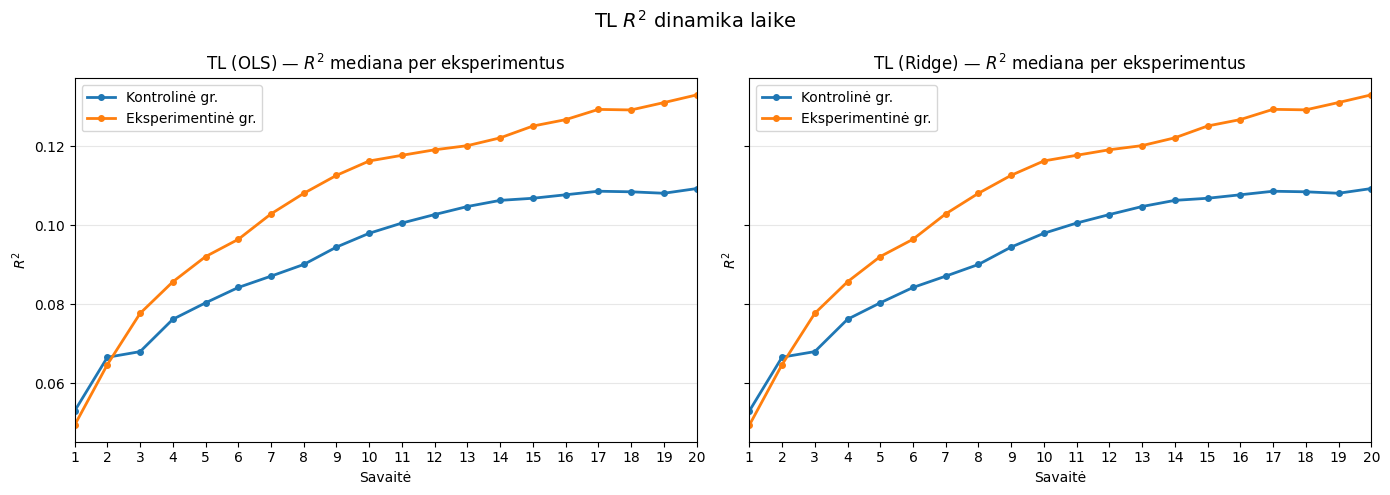

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, r2_df, title in [
    (axes[0], r2_df_ols, "TL (OLS)"),
    (axes[1], r2_df_ridge, "TL (Ridge)"),
]:
    for col, lbl, c in [
        ("r2_control", "Kontrolinė gr.", "#1f77b4"),
        ("r2_treated", "Eksperimentinė gr.", "#ff7f0e"),
    ]:
        med = r2_df.groupby("week")[col].median()
        ax.plot(med.index, med.values, color=c, marker="o", markersize=4, linewidth=2, label=lbl)
    ax.set_xlim(min(ALL_WEEKS), max(ALL_WEEKS))
    ax.set_xticks(ALL_WEEKS)
    ax.set_xlabel("Savaitė")
    ax.set_ylabel("$R^2$")
    ax.set_title(f"{title} — $R^2$ mediana per eksperimentus", fontsize=12)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("TL $R^2$ dinamika laike", fontsize=14)
plt.tight_layout()
plt.show()

## 12. $R^2$ vs DS — TL (OLS) vs TL (Ridge)

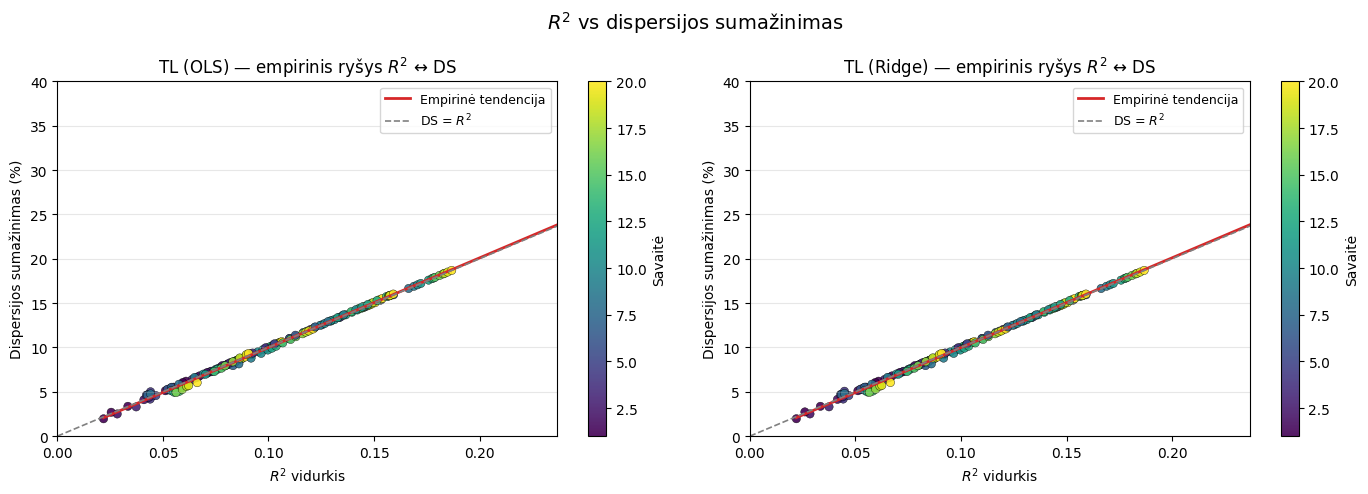

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method_key, r2_df, title in [
    (axes[0], "tl_ols",   r2_df_ols,   "TL (OLS)"),
    (axes[1], "tl_ridge", r2_df_ridge, "TL (Ridge)"),
]:
    ds = results_df[results_df["method"] == method_key][["experiment_id", "week", "ds"]].copy()
    r2_plot = r2_df.copy()
    r2_plot["r2_mean"] = (r2_plot["r2_control"] + r2_plot["r2_treated"]) / 2
    plot_df = ds.merge(r2_plot[["experiment_id", "week", "r2_mean"]], on=["experiment_id", "week"])
    plot_df["ds_pct"] = 100 * plot_df["ds"]

    x = plot_df["r2_mean"].to_numpy()
    y = plot_df["ds_pct"].to_numpy()

    sc = ax.scatter(x, y, c=plot_df["week"], cmap="viridis", alpha=0.9, edgecolor="black", linewidth=0.3)
    if len(plot_df) >= 2:
        b1, b0 = np.polyfit(x, y, 1)
        xg = np.linspace(max(0, np.nanmin(x)), np.nanmax(x) + 0.05, 100)
        ax.plot(xg, b1 * xg + b0, color="#d62728", linewidth=2, label="Empirinė tendencija")
    xline = np.linspace(0, max(0.01, np.nanmax(x) + 0.05), 100)
    ax.plot(xline, 100 * xline, color="gray", linestyle="--", linewidth=1.2, label="DS = $R^2$")
    plt.colorbar(sc, ax=ax).set_label("Savaitė")
    ax.set_xlim(0, max(0.01, np.nanmax(x) + 0.05))
    ax.set_ylim(0, 40)
    ax.set_xlabel("$R^2$ vidurkis")
    ax.set_ylabel("Dispersijos sumažinimas (%)")
    ax.set_title(f"{title} — empirinis ryšys $R^2$ ↔ DS", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("$R^2$ vs dispersijos sumažinimas", fontsize=14)
plt.tight_layout()
plt.show()

## 13. Standartizuotas ATE skirtumas — visi metodai

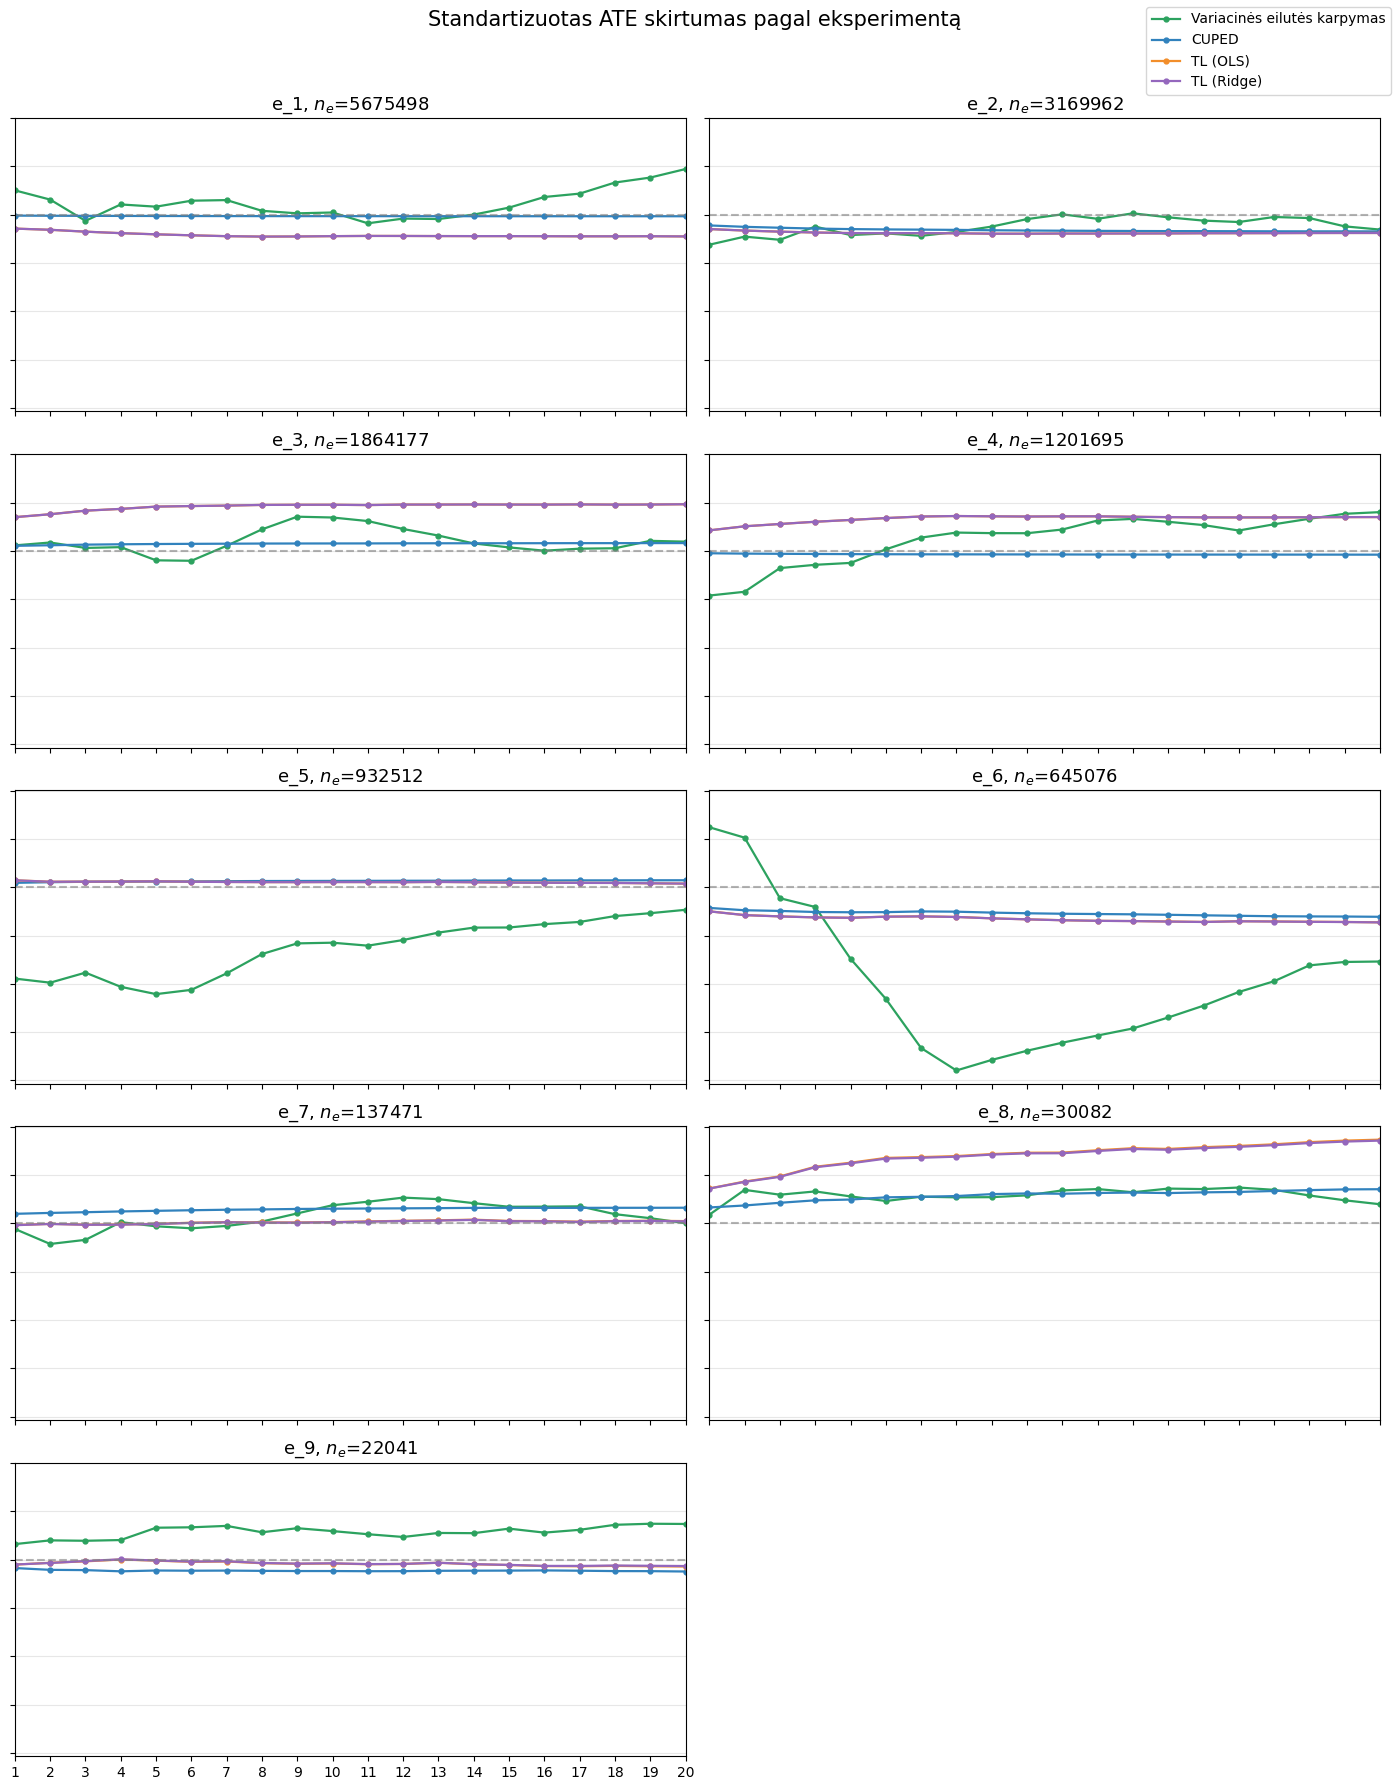

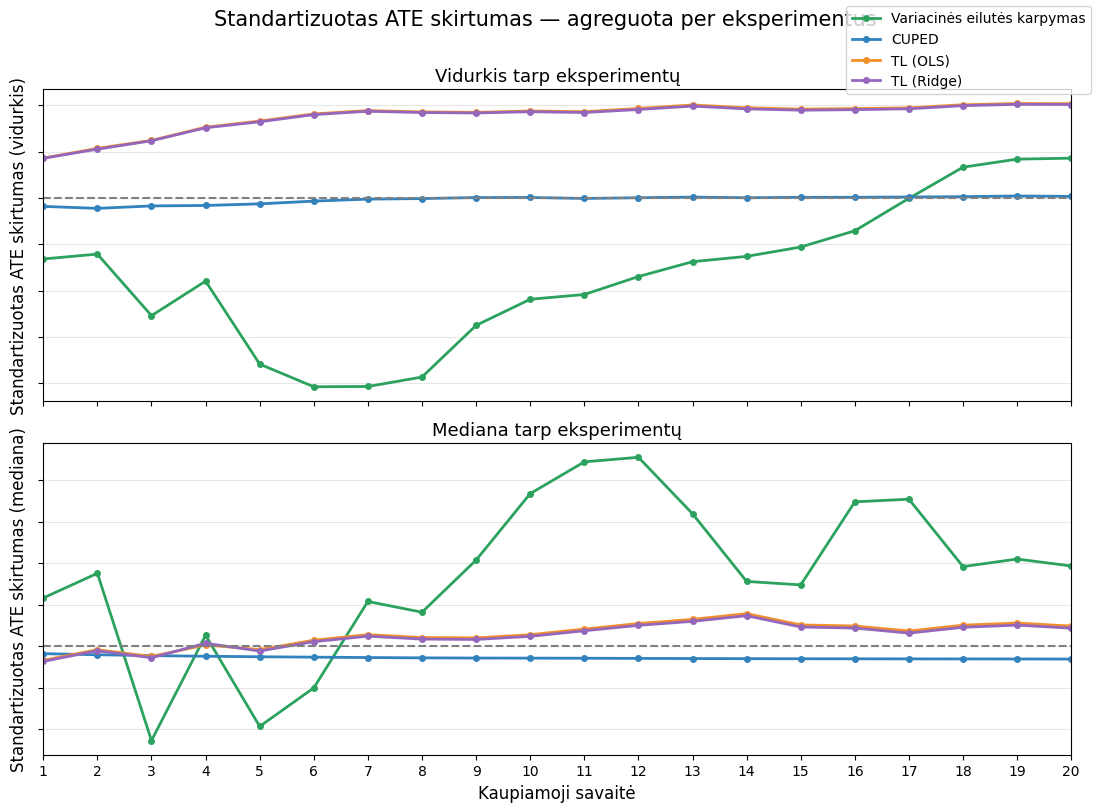

In [15]:
d = results_df[results_df["method"].isin(["winsor", "cuped", "tl_ols", "tl_ridge"])].copy()
methods = ["winsor", "cuped", "tl_ols", "tl_ridge"]
n_map = dict(zip(exp_summary_df["experiment_id"], exp_summary_df["n_e"]))

# Per experiment
n = len(exp_order)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, exp_id in enumerate(exp_order):
    ax = axes[i]
    sube = d[d["experiment_id"] == exp_id]
    for m in methods:
        s = sube[sube["method"] == m].sort_values("week")
        ax.plot(s["week"], s["std_diff"], color=METHOD_COLORS[m], marker="o",
                markersize=3.5, linewidth=1.6, label=METHOD_LABELS[m])
    ax.axhline(0, linestyle="--", color="gray", alpha=0.6)
    ax.set_xlim(min(ALL_WEEKS), max(ALL_WEEKS))
    ax.set_xticks(ALL_WEEKS)
    ax.set_yticklabels([])
    ax.set_title(f"{exp_label_map.get(exp_id, exp_id)}, $n_e$={n_map.get(exp_id)}", fontsize=13)
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.legend([METHOD_LABELS[m] for m in methods], loc="upper right", ncol=1)
fig.suptitle("Standartizuotas ATE skirtumas pagal eksperimentą", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Aggregated mean + median
fig, (ax_mean, ax_med) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for m in methods:
    g = d[d["method"] == m].groupby("week")["std_diff"]
    ax_mean.plot(g.mean().index, g.mean().values, color=METHOD_COLORS[m], marker="o",
                 markersize=4, linewidth=2, label=METHOD_LABELS[m])
    ax_med.plot(g.median().index, g.median().values, color=METHOD_COLORS[m], marker="o",
                markersize=4, linewidth=2, label=METHOD_LABELS[m])

for ax, title, ylab in [
    (ax_mean, "Vidurkis tarp eksperimentų", "Standartizuotas ATE skirtumas (vidurkis)"),
    (ax_med,  "Mediana tarp eksperimentų",  "Standartizuotas ATE skirtumas (mediana)"),
]:
    ax.axhline(0, linestyle="--", color="gray")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylab, fontsize=12)
    ax.set_xlim(min(ALL_WEEKS), max(ALL_WEEKS))
    ax.set_xticks(ALL_WEEKS)
    ax.set_yticklabels([])
    ax.grid(axis="y", alpha=0.3)

ax_med.set_xlabel("Kaupiamoji savaitė", fontsize=12)
fig.legend([METHOD_LABELS[m] for m in methods], loc="upper right", ncol=1)
fig.suptitle("Standartizuotas ATE skirtumas — agreguota per eksperimentus", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
table_2_ols = build_table_2(r2_df_ols, results_df, exp_summary_df, exp_label_map)
display(table_2_ols)

table_2_ridge = build_table_2(r2_df_ridge, results_df, exp_summary_df, exp_label_map)
table_2_ridge = table_2_ridge.rename(
    columns={"TL dispersijos sumažinimas (%)": "TL (Ridge) dispersijos sumažinimas (%)"}
)
display(table_2_ridge)

,Eksperimentas,n_e,R² kontrolės grupei,R² testinei grupei,TL dispersijos sumažinimas (%)
0,e_1,5.675498e+06,0.155369,0.145615,15.040825
1,e_2,3.169962e+06,0.108435,0.104219,10.652640
2,e_3,1.864177e+06,0.188266,0.185327,18.685154
3,e_4,1.201695e+06,0.089186,0.088777,8.926088
4,e_5,9.325120e+05,0.158850,0.149050,15.520729
5,e_6,6.450760e+05,0.109289,0.133000,12.075927
6,e_7,1.374710e+05,0.162562,0.155711,16.016127
7,e_8,3.008200e+04,0.081468,0.099668,9.315827
8,e_9,2.204100e+04,0.093867,0.038582,6.027989
9,Vidurkis,1.519835e+06,0.127477,0.122217,12.473478


,Eksperimentas,n_e,R² kontrolės grupei,R² testinei grupei,TL (Ridge) dispersijos sumažinimas (%)
0,e_1,5.675498e+06,0.155369,0.145615,15.040825
1,e_2,3.169962e+06,0.108436,0.104219,10.652640
2,e_3,1.864177e+06,0.188272,0.185328,18.685154
3,e_4,1.201695e+06,0.089187,0.088811,8.926088
4,e_5,9.325120e+05,0.158861,0.149059,15.520729
5,e_6,6.450760e+05,0.109299,0.133022,12.075927
6,e_7,1.374710e+05,0.162618,0.155767,16.016127
7,e_8,3.008200e+04,0.081645,0.100046,9.315827
8,e_9,2.204100e+04,0.094305,0.038827,6.027989
9,Vidurkis,1.519835e+06,0.127555,0.122299,12.473478


In [ ]:
# TL OLS vs TL Ridge W20 side-by-side
w20 = results_df[results_df["week"] == 20].copy()
w20 = w20[w20["method"].isin(["tl_ols", "tl_ridge"])]
w20["Eksperimentas"] = w20["experiment_id"].map(exp_label_map)
w20["Metodas"] = w20["method"].map(METHOD_LABELS)

display(
    w20[["Eksperimentas", "Metodas", "tau", "se", "ds", "std_diff"]]
    .sort_values(["Eksperimentas", "Metodas"])
)